In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from joblib import dump, load

# Métricas e ferramentas de Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import preprocessing
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

,sample_id,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,GSM2278615,1.030720,1.152392,-0.321811,-0.388305,-0.632559,-0.006389,-0.173028,0.734924,-0.538253,...,0.558312,0.682544,-0.281433,-0.152731,-0.136623,0.091852,-0.503763,1.053621,1,train
1,GSM2278616,1.773204,0.953377,-0.173949,-0.473914,-0.558560,0.032618,0.436156,0.842601,-0.515910,...,2.327494,0.270474,-1.432550,0.126085,1.908569,-0.476252,-0.810687,0.903694,1,train
2,GSM2278617,0.684740,0.403192,-0.496596,-0.608497,-0.066235,-1.190762,2.336523,0.121293,-0.042676,...,0.379008,0.212516,-0.912393,2.028289,-0.133262,-1.409829,-0.114039,0.013329,1,train
3,GSM2278618,-0.794088,-1.039456,-0.325646,-0.392525,-0.382181,-0.085807,0.056988,1.684487,-0.236236,...,1.159776,-0.186710,-1.223107,0.149769,-0.128983,-1.642710,0.321930,0.527365,1,train
4,GSM2278619,-1.453257,-0.910481,-0.491062,-0.424341,-0.479572,-0.036304,0.178505,0.631550,-0.728127,...,-0.839302,-0.348432,-0.809020,0.294022,0.486672,-1.282433,-1.035871,0.367641,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,GSM1447837,1.328089,0.849867,1.410876,2.054690,1.477953,1.944974,-0.440131,-0.042935,-0.007901,...,-0.860789,-0.101230,0.246102,-0.030673,-1.283171,1.365195,0.346937,-0.132385,0,train
281,GSM1447839,-1.429717,-1.267393,1.671507,2.089174,1.935565,-0.035735,0.167215,-0.624830,0.249774,...,-1.316962,1.582785,1.226486,-3.219079,-1.514643,2.006021,1.122274,-2.233914,0,train
282,GSM1447840,-0.345422,-0.366692,1.147987,1.722085,1.612545,0.596328,-0.269979,-1.103681,0.572284,...,-0.574166,-0.939608,2.324517,-1.450733,-0.072031,0.567534,1.845342,-0.367161,0,train
283,GSM1447841,-0.365179,-1.267393,0.078382,1.693163,1.418407,0.877449,-1.697361,-0.624830,0.445940,...,0.511769,-0.565786,0.997730,-1.529889,0.126708,0.120642,1.411211,1.093030,0,train


In [2]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_Tree_SVM/normalizador_TCC_Tree_SVM.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,MIMAT0018192,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,0.642643,0.556037,0.507214,0.198630,0.352515,0.568801,0.397176,0.449194,0.413662,0.444543,...,0.624663,0.630741,0.442053,0.527822,0.615689,0.483571,0.342527,0.473657,1,train
1,0.773114,0.515801,0.533194,0.175908,0.368558,0.574554,0.508098,0.465468,0.418135,0.570501,...,0.934508,0.569896,0.242716,0.575816,0.936687,0.406730,0.288510,0.452056,1,train
2,0.581846,0.404566,0.476502,0.140186,0.475293,0.394103,0.854120,0.356452,0.512861,0.398060,...,0.593260,0.561338,0.332790,0.903250,0.616216,0.280456,0.411117,0.323775,1,train
3,0.321981,0.112897,0.506540,0.197510,0.406797,0.557086,0.439058,0.592709,0.474116,0.511615,...,0.730000,0.502390,0.278985,0.579893,0.616888,0.248957,0.487846,0.397836,1,train
4,0.206149,0.138973,0.477475,0.189066,0.385683,0.564388,0.461184,0.433571,0.375656,0.608076,...,0.379892,0.478510,0.350691,0.604724,0.713517,0.297687,0.248878,0.374823,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0.694897,0.494874,0.811663,0.847058,0.810070,0.856631,0.348542,0.331630,0.519822,0.579420,...,0.376128,0.515011,0.533405,0.548833,0.435735,0.655801,0.492248,0.302781,0,train
281,0.210286,0.066814,0.857459,0.856211,0.909279,0.564472,0.459128,0.243684,0.571400,0.609914,...,0.296237,0.763669,0.703176,0.000000,0.399405,0.742478,0.628704,0.000000,0,train
282,0.400822,0.248914,0.765471,0.758777,0.839249,0.657703,0.379523,0.171312,0.635956,0.782556,...,0.426326,0.391219,0.893320,0.304392,0.625827,0.547911,0.755962,0.268956,0,train
283,0.397350,0.066814,0.577531,0.751101,0.797160,0.699169,0.119623,0.243684,0.610666,1.000000,...,0.616511,0.446416,0.663563,0.290767,0.657019,0.487465,0.679556,0.479335,0,train


In [3]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------
Counter({np.int64(1): 150, np.int64(0): 150})


In [4]:
# Preparar conjuntos de treino/teste a partir da coluna 'split' (ajustado para nova base)
# Criar features e target
features = dados_final.drop(columns=['target','split']).columns
X = dados_final[features].fillna(dados_final[features].mean())
y = dados_final['target'].values

if 'split' in dados_final.columns:
    split_series = dados_final['split'].astype(str).str.lower()
    if ('train' in split_series.values) and ('test' in split_series.values):
        train_mask = split_series == 'train'
        X_train = X[train_mask].values
        y_train = y[train_mask.values]
        X_test = X[~train_mask].values
        y_test = y[~train_mask.values]
    else:
        # fallback: if split is numeric (e.g., 0/1) assume one unique value indicates train
        unique = dados_final['split'].unique()
        if len(unique) == 2:
            train_val = unique[0]
            train_mask = dados_final['split'] == train_val
            X_train = X[train_mask].values
            y_train = y[train_mask.values]
            X_test = X[~train_mask].values
            y_test = y[~train_mask.values]
        else:
            # no usable split, create stratified train/test (20% test)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
else:
    # no split column, fallback to stratified split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('Tamanho treino:', X_train.shape, 'tamanho teste:', X_test.shape)

# Pipeline com scaler -> SMOTE -> SVC. SMOTE será aplicado apenas nos folds/treino via pipeline do imblearn
pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
])

param_grid = {
    'svc__kernel': ['rbf', 'linear'],
    'svc__C': [0.1, 1.0, 10.0],
    'svc__gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)

print('Iniciando ajuste de hiperparâmetros com GridSearchCV...')
grid.fit(X_train, y_train)
print('Melhor combinação:', grid.best_params_)
best_model = grid.best_estimator_

# Salvar o melhor modelo
os.makedirs('models_SVM', exist_ok=True)
dump(best_model, os.path.join('models_SVM', 'modelo_SVM_TCC.joblib'))
print('Modelo salvo em models_SVM/modelo_SVM_TCC.joblib')

Tamanho treino: (228, 33) tamanho teste: (57, 33)
Iniciando ajuste de hiperparâmetros com GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhor combinação: {'svc__C': 10.0, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Modelo salvo em models_SVM/modelo_SVM_TCC.joblib


c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


              precision    recall  f1-score   support

           0     1.0000    0.9259    0.9615        27
           1     0.9375    1.0000    0.9677        30

    accuracy                         0.9649        57
   macro avg     0.9688    0.9630    0.9646        57
weighted avg     0.9671    0.9649    0.9648        57

Accuracy: 0.9649122807017544
ROC AUC: 0.9925925925925926


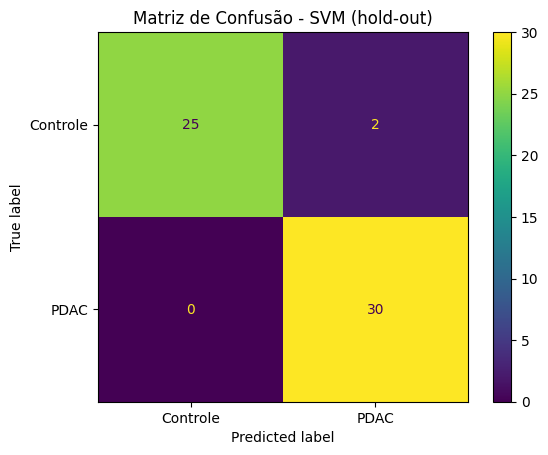

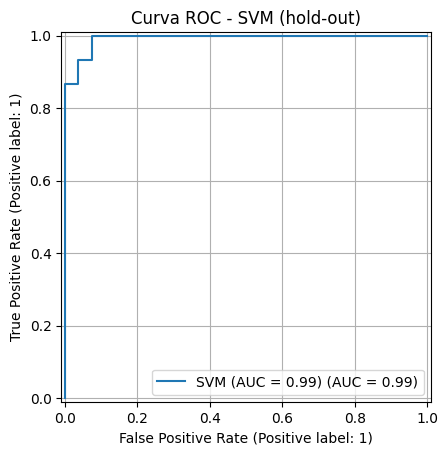

In [5]:
# Avaliação no hold-out final (não visto durante o ajuste)
modelo = best_model
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Controle','PDAC'])
disp.plot(cmap='viridis')
plt.title('Matriz de Confusão - SVM (hold-out)')
plt.show()

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba, name=f'SVM (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.title('Curva ROC - SVM (hold-out)')
plt.grid(True)
plt.show()